# Statistical Analysis (Python)

This notebook uses **pandas**, **scipy**, **statsmodels**, and **seaborn** for exploratory analysis, hypothesis testing, and regression.

Data files live in `../data/`:

- `iris.csv` — Fisher iris measurements by species
- `wages.csv` — 1985 CPS wage determinants (534 workers)
- `brain_size.csv` — brain size and IQ measures by gender


## Setup

Import libraries and configure paths and plotting defaults.


In [1]:
# Core libraries for data handling, statistics, and visualization
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [2]:
# Resolve data directory relative to this notebook
DATA_DIR = Path("../data").resolve()

# Plotting and display defaults
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

print(f"Data directory: {DATA_DIR}")
print("Available files:")
for path in sorted(DATA_DIR.glob("*.csv")):
    print(f"  - {path.name}")


Data directory: /Users/coraalbers/Documents/sum26/7030_data_sci/assignment4/data
Available files:
  - brain_size.csv
  - iris.csv
  - wages.csv


## Load data

Define helper functions to read each CSV with the correct delimiter and column names, then preview the datasets.


In [3]:
# Column names for wages.csv (whitespace-separated, no header row)
WAGES_COLUMNS = [
    "education",
    "south",
    "sex",
    "experience",
    "union",
    "wage",
    "age",
    "race",
    "occupation",
    "sector",
    "marr",
]


def load_iris() -> pd.DataFrame:
    return pd.read_csv(DATA_DIR / "iris.csv")


def load_wages() -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / "wages.csv",
        sep=r"\s+",
        skiprows=27,  # skip metadata header
        nrows=534,
        header=None,
        names=WAGES_COLUMNS,
        engine="python",
    )
    # Recode sex as strings; log-transform wage for variance stabilization
    df["sex"] = df["sex"].map({0: "Male", 1: "Female"}).astype("string")
    df["wage"] = np.log10(df["wage"])
    return df


def load_brain_size() -> pd.DataFrame:
    df = pd.read_csv(
        DATA_DIR / "brain_size.csv",
        sep=";",
        quotechar='"',
    )
    df.columns = [col.strip('"') for col in df.columns]
    numeric_cols = ["FSIQ", "VIQ", "PIQ", "Weight", "Height", "MRI_Count"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col].replace(".", np.nan), errors="coerce")
    return df


In [4]:
# Load all datasets and preview the first rows
iris = load_iris()
wages = load_wages()
brain_size = load_brain_size()

print("Iris:", iris.shape)
display(iris.head())

print("\nWages:", wages.shape)
display(wages.head())

print("\nBrain size:", brain_size.shape)
display(brain_size.head())


Iris: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,name
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Wages: (534, 11)


,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,Female,21,0,0.707570,35,2,6,1,1
1,9,0,Female,42,0,0.694605,57,3,6,1,1
2,12,0,Male,1,0,0.824126,19,3,6,1,0
3,12,0,Male,4,0,0.602060,22,3,6,0,0
4,12,0,Male,17,0,0.875061,35,3,6,0,1



Brain size: (40, 8)


,Unnamed: 0,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,1,Female,133,132,124,118.0,64.5,816932
1,2,Male,140,150,124,NaN,72.5,1001121
2,3,Male,139,123,150,143.0,73.3,1038437
3,4,Male,133,129,128,172.0,68.8,965353
4,5,Female,137,132,134,147.0,65.0,951545


## Brain size analysis

Explore IQ and body measurements in the brain size dataset, comparing males and females.


### Group means

Split the data by gender and compute the mean of each numeric column.


In [5]:
numeric_cols = ["FSIQ", "VIQ", "PIQ", "Weight", "Height", "MRI_Count"]

gender_means = brain_size.groupby("Gender")[numeric_cols].mean()
display(gender_means)


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,115.0,115.25,111.60,166.444444,71.431579,954855.4


### IQ distributions by gender

Box plots show the spread of FSIQ, VIQ, and PIQ for each gender.


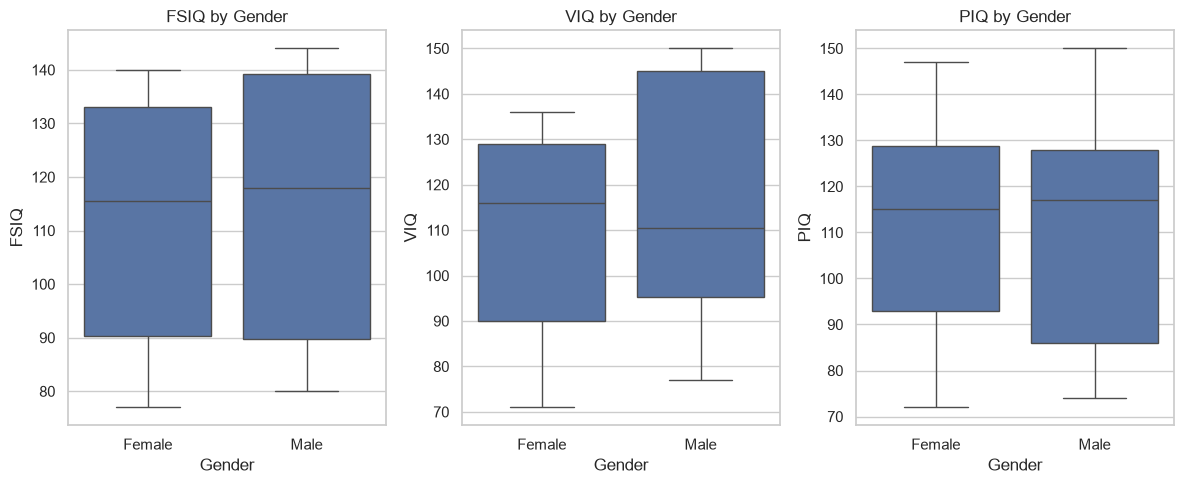

In [6]:
iq_cols = ["FSIQ", "VIQ", "PIQ"]

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for ax, col in zip(axes, iq_cols):
    sns.boxplot(data=brain_size, x="Gender", y=col, ax=ax)
    ax.set_title(f"{col} by Gender")

plt.tight_layout()
plt.show()


### Summary statistics

Single-number summaries for VIQ, sample size by gender, and mean log MRI count.


In [7]:
# Mean VIQ across all participants
viq_mean = brain_size["VIQ"].mean()
print(f"Mean VIQ (full population): {viq_mean:.2f}")

# Count males and females in the study
gender_counts = brain_size["Gender"].value_counts()
display(gender_counts)

# Average MRI count on the log scale, by gender
log_mri_means = (
    brain_size.assign(log_MRI_Count=np.log(brain_size["MRI_Count"]))
    .groupby("Gender")["log_MRI_Count"]
    .mean()
)
display(log_mri_means)


Mean VIQ (full population): 112.35


Gender
Female    20
Male      20
Name: count, dtype: int64

Gender
Female    13.665830
Male      13.767731
Name: log_MRI_Count, dtype: float64

### Scatter matrices

Pair plots visualize relationships among measurements, colored by gender.


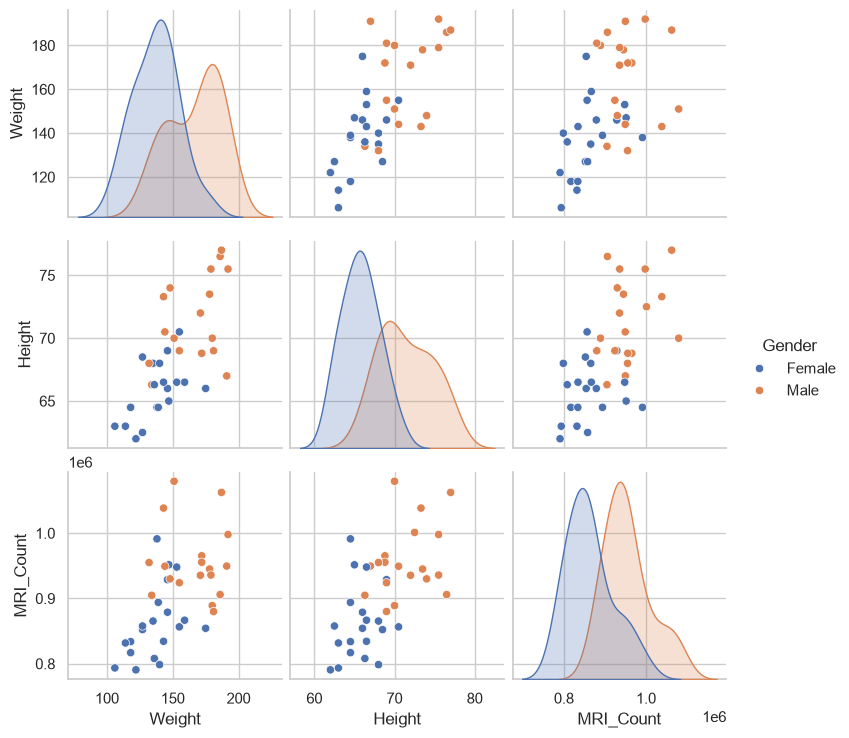

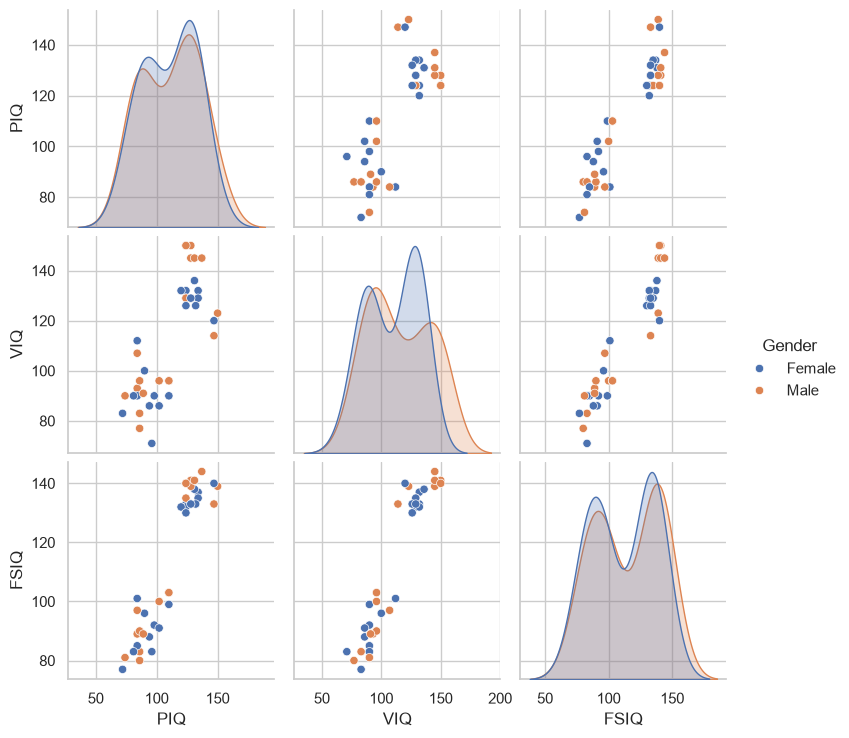

In [8]:
# Body measurements: weight, height, MRI count
body_cols = ["Weight", "Height", "MRI_Count"]
sns.pairplot(brain_size, vars=body_cols, hue="Gender", corner=False)
plt.show()

# IQ measures: PIQ, VIQ, FSIQ
iq_cols = ["PIQ", "VIQ", "FSIQ"]
sns.pairplot(brain_size, vars=iq_cols, hue="Gender", corner=False)
plt.show()


## Statistics

Hypothesis tests on the brain size data using scipy.


### One-sample tests for VIQ

Test whether mean VIQ differs from zero using parametric and non-parametric tests.


In [9]:
# One-sample t-test: H0 mean VIQ = 0
viq_ttest = stats.ttest_1samp(brain_size["VIQ"], popmean=0)
print(f"t-statistic: {viq_ttest.statistic:.4f}")
print(f"p-value: {viq_ttest.pvalue:.4g}")

# Wilcoxon signed-rank test (non-parametric alternative)
viq_wilcoxon = stats.wilcoxon(brain_size["VIQ"])
print(f"\nWilcoxon statistic: {viq_wilcoxon.statistic:.4f}")
print(f"p-value: {viq_wilcoxon.pvalue:.4g}")


t-statistic: 30.0881
p-value: 1.329e-28

Wilcoxon statistic: 0.0000
p-value: 3.488e-08


### Two-sample tests: female vs male VIQ

Compare VIQ between genders using t-test and Mann-Whitney U test.


In [10]:
female_viq = brain_size.loc[brain_size["Gender"] == "Female", "VIQ"]
male_viq = brain_size.loc[brain_size["Gender"] == "Male", "VIQ"]

# Independent-samples t-test
viq_gender_ttest = stats.ttest_ind(female_viq, male_viq)
print(f"t-statistic: {viq_gender_ttest.statistic:.4f}")
print(f"p-value: {viq_gender_ttest.pvalue:.4g}")

# Mann-Whitney U test (non-parametric)
viq_mannwhitney = stats.mannwhitneyu(female_viq, male_viq)
print(f"\nMann-Whitney statistic: {viq_mannwhitney.statistic:.4f}")
print(f"p-value: {viq_mannwhitney.pvalue:.4g}")


t-statistic: -0.7726
p-value: 0.4445

Mann-Whitney statistic: 164.5000
p-value: 0.3423


### FSIQ vs PIQ

Compare FSIQ and PIQ with paired and unpaired t-tests, then visualize their difference.


Unpaired t-test (FSIQ vs PIQ):
t-statistic: 0.4656
p-value: 0.6428

Paired t-test (FSIQ vs PIQ):
t-statistic: 1.7842
p-value: 0.08217


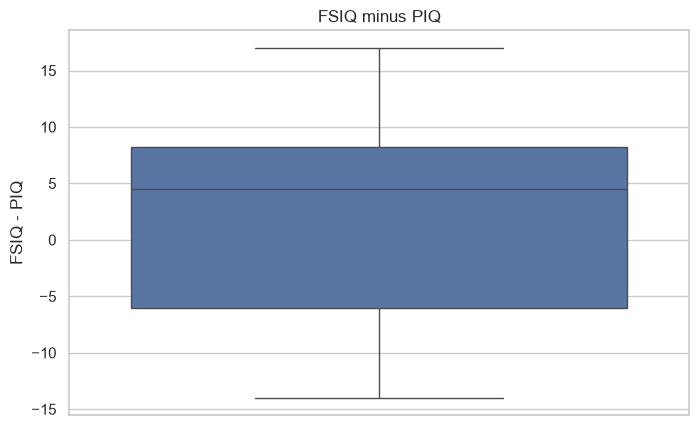

In [11]:
# Unpaired t-test treats the two columns as independent samples
fsiq_piq_unpaired = stats.ttest_ind(brain_size["FSIQ"], brain_size["PIQ"])
print("Unpaired t-test (FSIQ vs PIQ):")
print(f"t-statistic: {fsiq_piq_unpaired.statistic:.4f}")
print(f"p-value: {fsiq_piq_unpaired.pvalue:.4g}")

# Paired t-test accounts for repeated measures on the same subjects
fsiq_piq_paired = stats.ttest_rel(brain_size["FSIQ"], brain_size["PIQ"])
print("\nPaired t-test (FSIQ vs PIQ):")
print(f"t-statistic: {fsiq_piq_paired.statistic:.4f}")
print(f"p-value: {fsiq_piq_paired.pvalue:.4g}")

# Box plot of within-subject differences
fsiq_piq_diff = brain_size["FSIQ"] - brain_size["PIQ"]
sns.boxplot(y=fsiq_piq_diff)
plt.ylabel("FSIQ - PIQ")
plt.title("FSIQ minus PIQ")
plt.show()


## Linear models

Introduction to OLS regression with simulated data, then applied to brain size.


### Simulated linear data

Generate reproducible data with a known linear relationship plus normal noise.


In [12]:
# Fixed seed for reproducibility; true model is y = 3 + 2x + noise
rng = np.random.default_rng(42)

n = 100
x = rng.uniform(0, 10, size=n)
noise = rng.normal(loc=0, scale=2, size=n)
y = 3 + 2 * x + noise

sim_data = pd.DataFrame({"x": x, "y": y})
display(sim_data.head())


,x,y
0,7.739560,19.278669
1,4.388784,9.966611
2,8.585979,19.415633
3,6.973680,19.545817
4,0.941773,4.171019


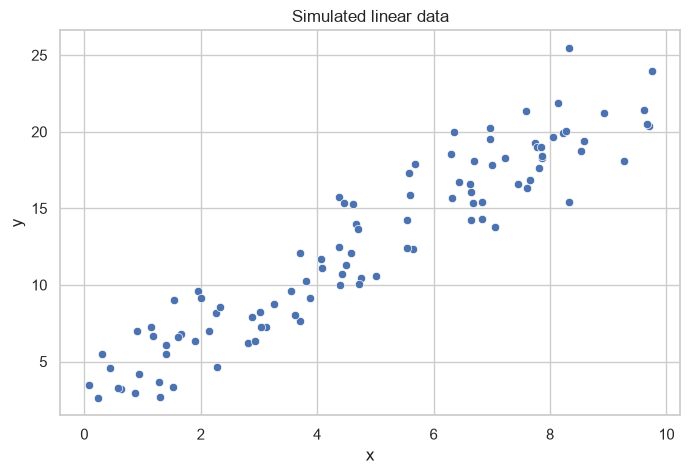

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     769.2
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           3.41e-48
Time:                        15:50:19   Log-Likelihood:                -209.11
No. Observations:                 100   AIC:                             422.2
Df Residuals:                      98   BIC:                             427.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.8974      0.405      7.150      0.0

In [13]:
# Visualize the simulated relationship
sns.scatterplot(data=sim_data, x="x", y="y")
plt.title("Simulated linear data")
plt.show()

# Fit OLS and print the regression table
ols_model = smf.ols("y ~ x", data=sim_data).fit()
print(ols_model.summary())


### VIQ by gender (brain size data)

Use OLS with gender as a categorical predictor of VIQ.


In [14]:
# Female is the reference category; Male coefficient is the group difference
viq_gender_ols = smf.ols("VIQ ~ C(Gender)", data=brain_size).fit()
print(viq_gender_ols.summary())


                            OLS Regression Results                            
Dep. Variable:                    VIQ   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.5969
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.445
Time:                        15:50:19   Log-Likelihood:                -182.42
No. Observations:                  40   AIC:                             368.8
Df Residuals:                      38   BIC:                             372.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           109.4500      5.30

### FSIQ vs PIQ (long format)

Reshape to long form so IQ type is a single categorical column, then compare with OLS.


In [15]:
# Stack FSIQ and PIQ into rows with columns: type, iq
iq_long = pd.melt(
    brain_size,
    value_vars=["FSIQ", "PIQ"],
    var_name="type",
    value_name="iq",
)[["type", "iq"]]

display(iq_long.head())
print(f"Shape: {iq_long.shape}")

# OLS compares mean iq across type (FSIQ is reference)
iq_type_ols = smf.ols("iq ~ C(type)", data=iq_long).fit()
print(iq_type_ols.summary())


,type,iq
0,FSIQ,133
1,FSIQ,140
2,FSIQ,139
3,FSIQ,133
4,FSIQ,137


Shape: (80, 2)
                            OLS Regression Results                            
Dep. Variable:                     iq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                    0.2168
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.643
Time:                        15:50:19   Log-Likelihood:                -364.35
No. Observations:                  80   AIC:                             732.7
Df Residuals:                      78   BIC:                             737.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        113.4500    

## Multiple regression

Analyze iris data with categorical species and continuous predictors.


### Load and explore iris data

Reload iris and encode species as a categorical variable for modeling.


In [16]:
iris = load_iris()
iris["categories"] = pd.Categorical(iris["name"])

display(iris.head())


,sepal_length,sepal_width,petal_length,petal_width,name,categories
0,5.1,3.5,1.4,0.2,setosa,setosa
1,4.9,3.0,1.4,0.2,setosa,setosa
2,4.7,3.2,1.3,0.2,setosa,setosa
3,4.6,3.1,1.5,0.2,setosa,setosa
4,5.0,3.6,1.4,0.2,setosa,setosa


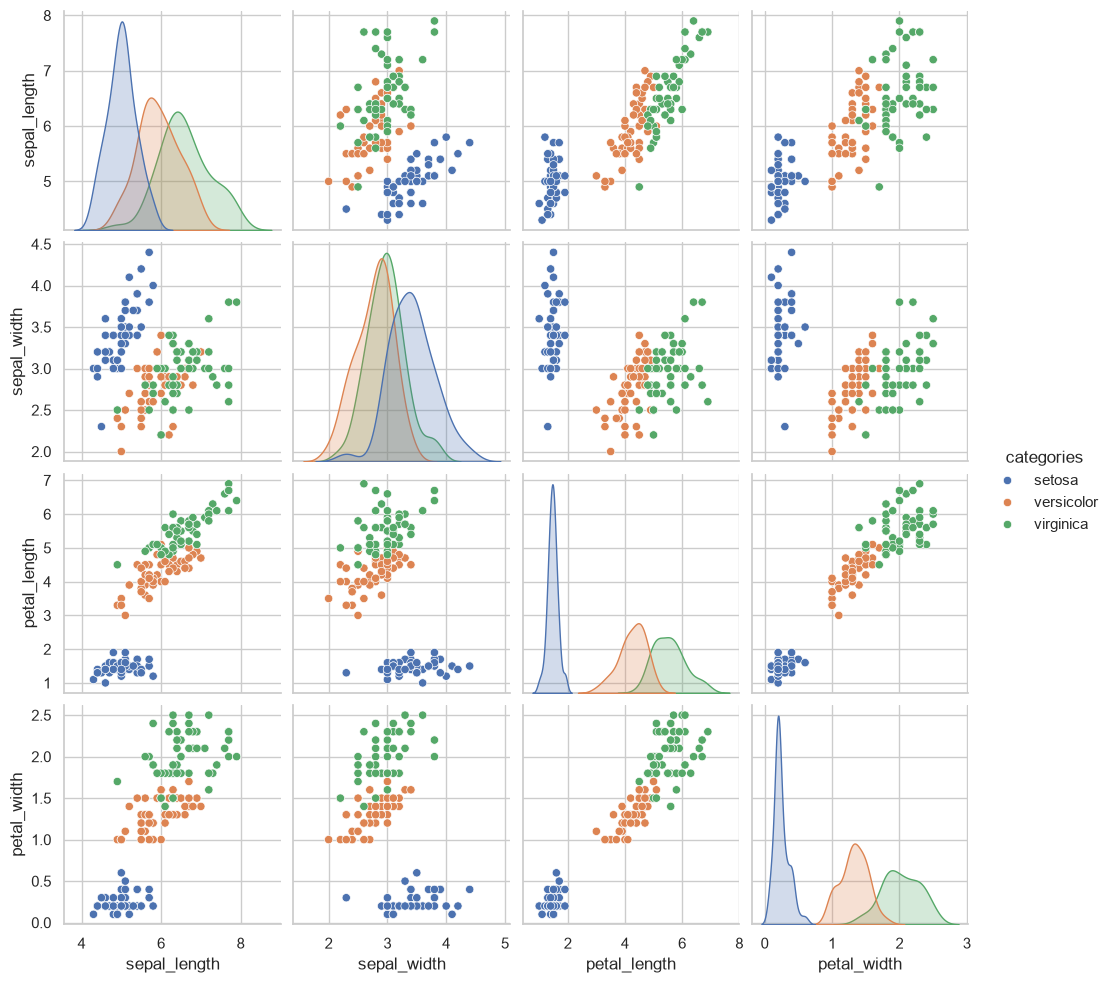

In [17]:
# Scatter matrix of measurements, colored by species
iris_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
sns.pairplot(iris, vars=iris_cols, hue="categories", corner=False)
plt.show()


### Regression and contrasts

Fit a multiple regression model, then test a specific contrast between species coefficients.


In [18]:
# Sepal width as a function of species and petal length
sepal_model = smf.ols("sepal_width ~ C(name) + petal_length", data=iris).fit()
print(sepal_model.summary())

# Contrast: versicolor coefficient minus virginica coefficient = 0
# Parameter order: Intercept, C(name)[T.versicolor], C(name)[T.virginica], petal_length
contrast = np.array([0, 1, -1, 0])
versicolor_virginica_test = sepal_model.f_test(contrast)
print(versicolor_virginica_test)


                            OLS Regression Results                            
Dep. Variable:            sepal_width   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     44.63
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           1.58e-20
Time:                        15:50:20   Log-Likelihood:                -38.185
No. Observations:                 150   AIC:                             84.37
Df Residuals:                     146   BIC:                             96.41
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.98

## Wages

Analyze log-transformed wages as a function of education and sex.


### Load and explore wages

Reload wages (sex as strings, wage as log10) and visualize key variables.


In [19]:
wages = load_wages()

display(wages.head())
print(f"Shape: {wages.shape}")
print(wages[["wage", "age", "education"]].dtypes)


,education,south,sex,experience,union,wage,age,race,occupation,sector,marr
0,8,0,Female,21,0,0.707570,35,2,6,1,1
1,9,0,Female,42,0,0.694605,57,3,6,1,1
2,12,0,Male,1,0,0.824126,19,3,6,1,0
3,12,0,Male,4,0,0.602060,22,3,6,0,0
4,12,0,Male,17,0,0.875061,35,3,6,0,1


Shape: (534, 11)
wage         float64
age            int64
education      int64
dtype: object


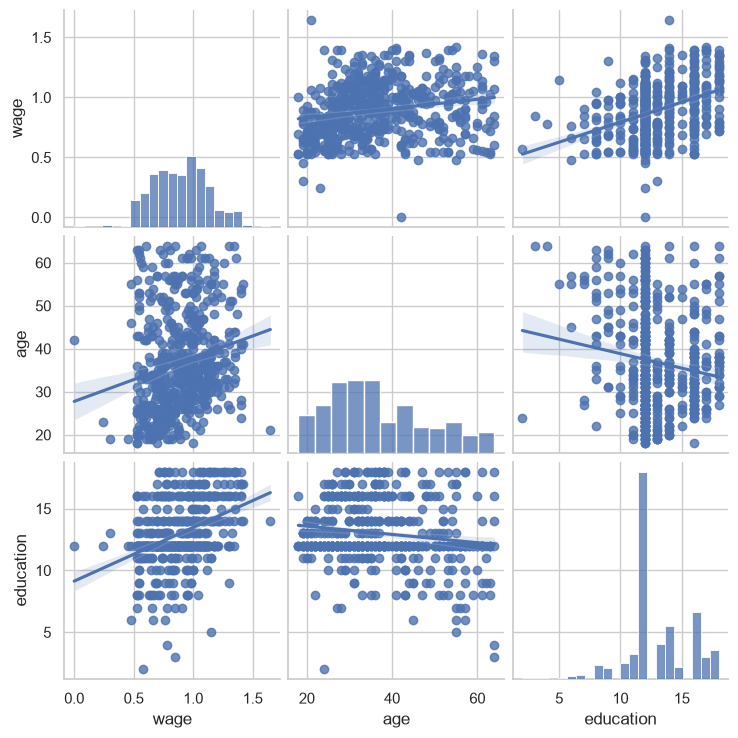

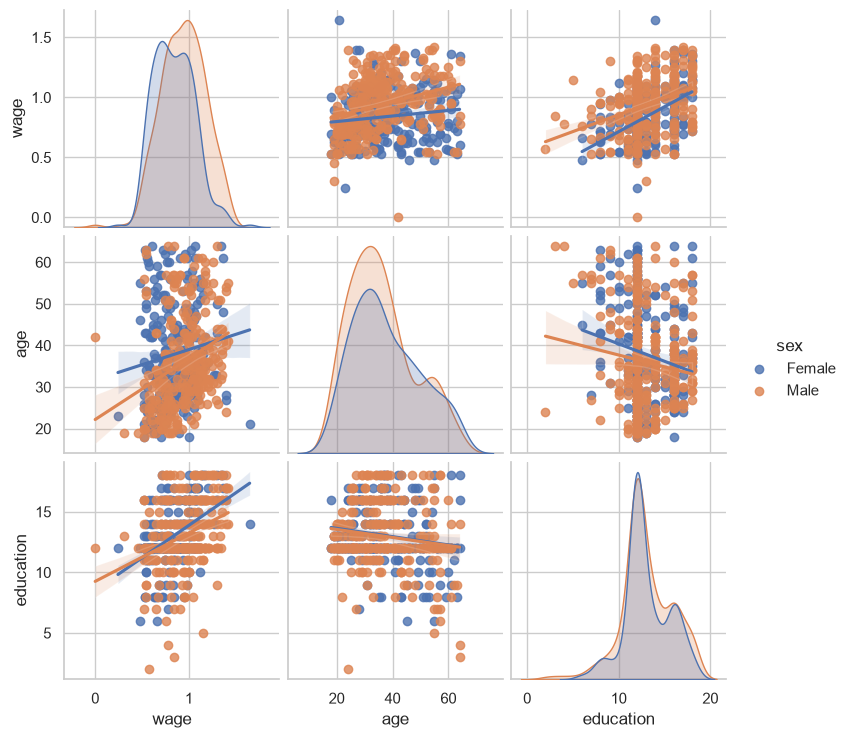

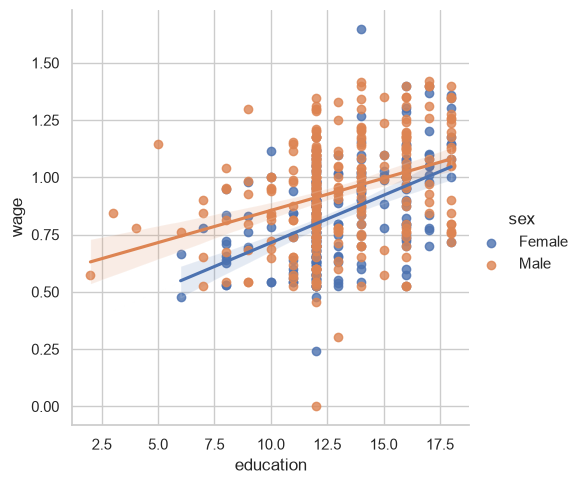

In [20]:
wages_cols = ["wage", "age", "education"]

# Pair plot with regression lines on off-diagonal panels
sns.pairplot(wages, vars=wages_cols, kind="reg", corner=False)
plt.show()

# Same variables, split by sex
sns.pairplot(wages, vars=wages_cols, hue="sex", kind="reg", corner=False)
plt.show()

# Focus on the education-wage relationship by sex
sns.lmplot(data=wages, x="education", y="wage", hue="sex")
plt.show()


### Wage regression models

Estimate main effects and an education-by-sex interaction on log wage.


In [21]:
# Main effects: education and sex separately
wage_model = smf.ols("wage ~ education + C(sex)", data=wages).fit()
print(wage_model.summary())

# Add interaction to test whether education slope differs by sex
wage_interaction_model = smf.ols(
    "wage ~ education + C(sex) + education:C(sex)",
    data=wages,
).fit()
print(wage_interaction_model.summary())


                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.193
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     63.42
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           2.01e-25
Time:                        15:50:21   Log-Likelihood:                 86.654
No. Observations:                 534   AIC:                            -167.3
Df Residuals:                     531   BIC:                            -154.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4053      0.046      8.